[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2285
[LightGBM] [Info] Number of data points in the train set: 104110, number of used features: 13
[LightGBM] [Info] Start training from score 2.326986

=== RESULTADOS ===
MAE Modelo: 16.46
MAE Final (Smart): 16.46
MAE Baseline: 23.04

Produto escolhido: 85099B


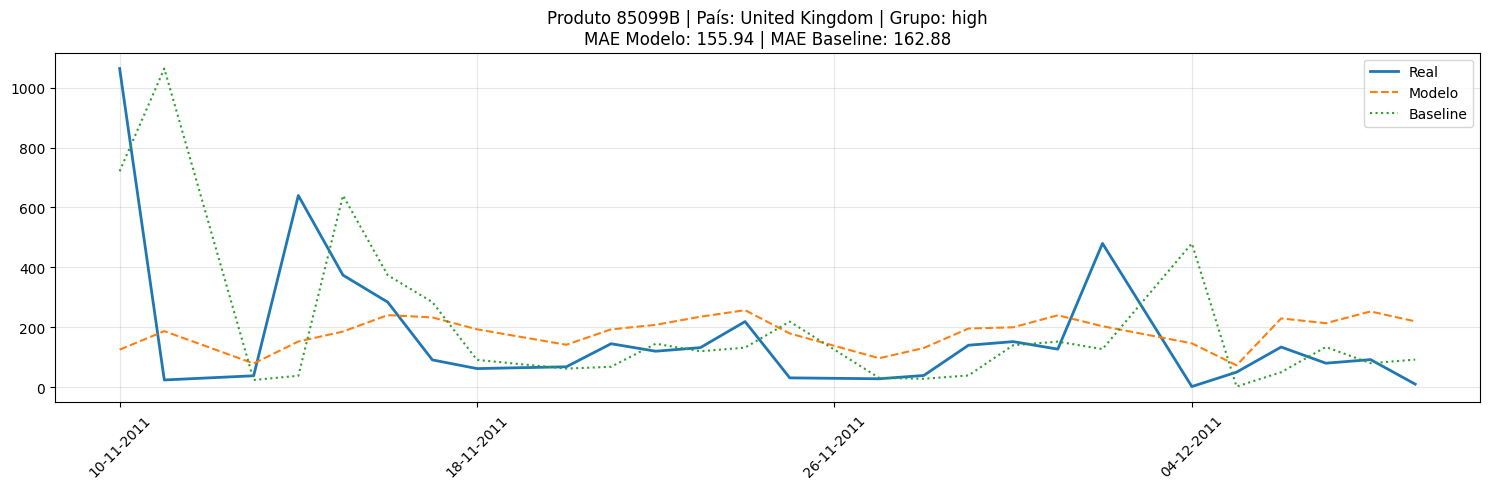

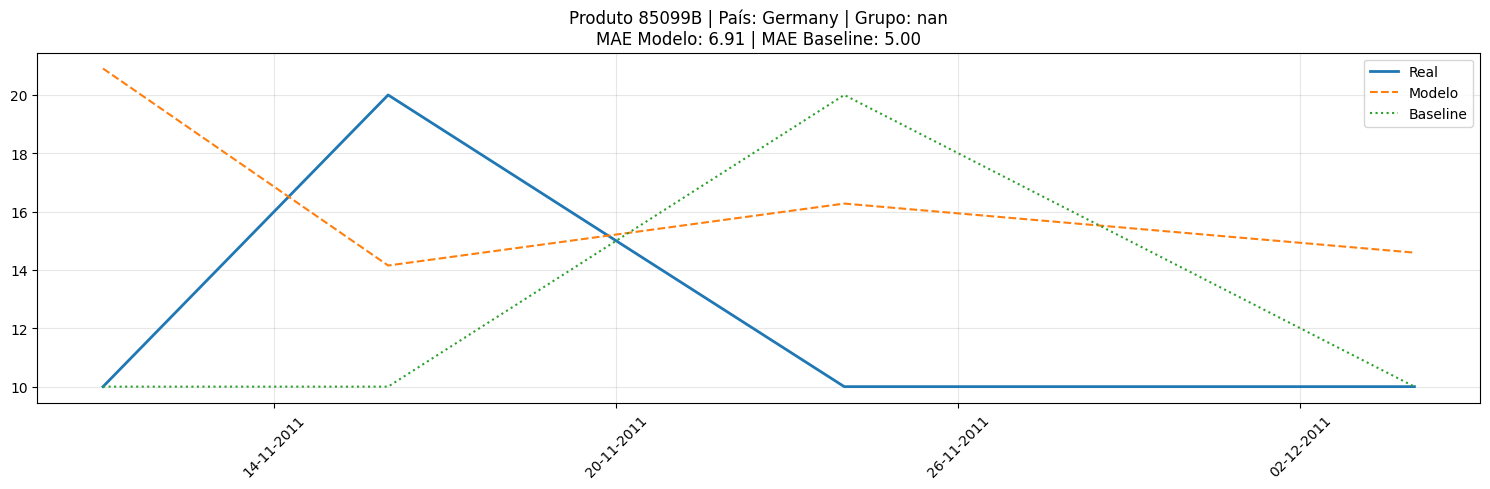

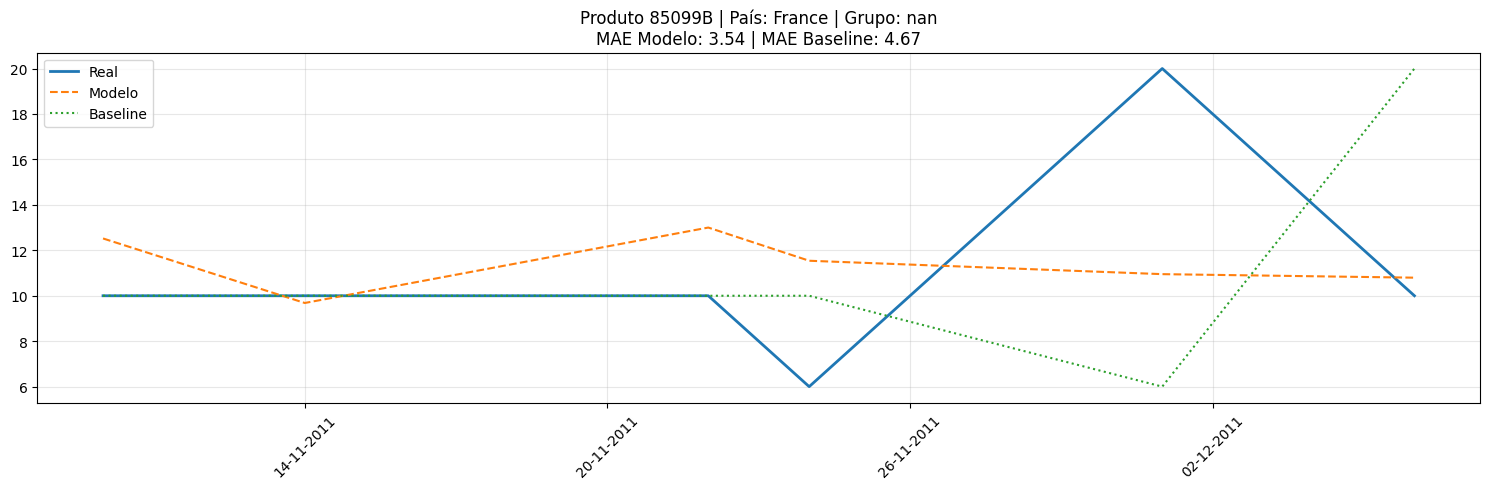

In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

from sklearn.metrics import mean_absolute_error

# =========================================
# 1. DADOS
# =========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df = df.dropna(subset=['CustomerID']).query('Quantity > 0')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()

# =========================================
# 2. AGREGAÇÃO (PRODUTO + PAÍS)
# =========================================
daily_sales = df.groupby(
    ['InvoiceDate', 'StockCode', 'Country']
)['Quantity'].sum().reset_index()

daily_sales = daily_sales.sort_values('InvoiceDate')

# =========================================
# 3. VARIÁVEIS
# =========================================
def create_features(df):
    df = df.copy()

    df['day_of_week'] = df['InvoiceDate'].dt.dayofweek
    df['month'] = df['InvoiceDate'].dt.month
    df['week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
    df['time_idx'] = (df['InvoiceDate'] - df['InvoiceDate'].min()).dt.days

    df['series_id'] = df['StockCode'].astype(str) + "_" + df['Country']

    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df.groupby('series_id')['Quantity'].shift(lag)

    for w in [7, 30]:
        df[f'rolling_mean_{w}'] = df.groupby('series_id')['Quantity'].transform(
            lambda x: x.rolling(w).mean().shift(1)
        )

    df['baseline_naive'] = df.groupby('series_id')['Quantity'].shift(1)

    return df.dropna()

data = create_features(daily_sales)

# =========================================
# 4. DIVISAO
# =========================================
split_date = data['InvoiceDate'].max() - pd.Timedelta(days=30)

train = data[data['InvoiceDate'] <= split_date].copy()
test = data[data['InvoiceDate'] > split_date].copy()

# =========================================
# 5. CLASSIFICAÇÃO DAS SÉRIES
# =========================================
stats = train.groupby('series_id')['Quantity'].agg(['mean', 'std', 'count'])

stats['cv'] = stats['std'] / (stats['mean'] + 1e-5)

presence = train.copy()
presence['has_sale'] = 1
presence = presence.groupby('series_id')['has_sale'].sum()

stats['density'] = presence / stats['count']

def classify(row):
    if row['density'] < 0.4:
        return 'intermittent'
    elif row['mean'] > stats['mean'].median():
        return 'high'
    else:
        return 'low'

stats['group'] = stats.apply(classify, axis=1)

train['group'] = train['series_id'].map(stats['group'])
test['group'] = test['series_id'].map(stats['group'])

# =========================================
# 6. ENCODING
# =========================================
prod_freq = train['StockCode'].value_counts()
country_freq = train['Country'].value_counts()
series_freq = train['series_id'].value_counts()

train['prod_freq'] = train['StockCode'].map(prod_freq)
test['prod_freq'] = test['StockCode'].map(prod_freq)

train['country_freq'] = train['Country'].map(country_freq)
test['country_freq'] = test['Country'].map(country_freq)

train['series_freq'] = train['series_id'].map(series_freq)
test['series_freq'] = test['series_id'].map(series_freq)

# =========================================
# 7. VARIAVEIS
# =========================================
features = [
    'day_of_week', 'month', 'week', 'time_idx',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30',
    'prod_freq', 'country_freq', 'series_freq'
]

# =========================================
# 8. MODELO GLOBAL
# =========================================
train['y'] = np.log1p(train['Quantity'])

model = lgb.LGBMRegressor(
    objective='huber',
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42
)

model.fit(train[features], train['y'])

# =========================================
# 9. PREDIÇÃO
# =========================================
test['pred_model'] = np.expm1(model.predict(test[features]))

# =========================================
# 10. DECISÃO POR COMPORTAMENTO
# =========================================
test['pred_final'] = np.where(
    test['group'] == 'intermittent',
    test['baseline_naive'],
    test['pred_model']
)

# =========================================
# 11. RESULTADOS GLOBAIS
# =========================================
mae_model = mean_absolute_error(test['Quantity'], test['pred_model'])
mae_final = mean_absolute_error(test['Quantity'], test['pred_final'])
mae_naive = mean_absolute_error(test['Quantity'], test['baseline_naive'])

print("\n=== RESULTADOS ===")
print(f"MAE Modelo: {mae_model:.2f}")
print(f"MAE Final (Smart): {mae_final:.2f}")
print(f"MAE Baseline: {mae_naive:.2f}")

# =========================================
# 12. ESCOLHER PAÍSES (MANUAL)
# =========================================
selected_countries = ['United Kingdom', 'Germany', 'France']

# =========================================
# 13. ESCOLHER PRODUTO QUE EXISTE NOS PAÍSES
# =========================================
prod_country_count = (
    test[test['Country'].isin(selected_countries)]
    .groupby('StockCode')['Country']
    .nunique()
)

valid_products = prod_country_count[
    prod_country_count == len(selected_countries)
].index

if len(valid_products) == 0:
    raise ValueError("Nenhum produto encontrado nos países selecionados")

product = (
    test[test['StockCode'].isin(valid_products)]
    .groupby('StockCode')['Quantity']
    .sum()
    .idxmax()
)

subset_prod = test[test['StockCode'] == product]

print(f"\nProduto escolhido: {product}")

# =========================================
# 14. PLOT (UM POR PAÍS)
# =========================================
for country in selected_countries:
    subset = subset_prod[subset_prod['Country'] == country].sort_values('InvoiceDate')

    mae_model = mean_absolute_error(subset['Quantity'], subset['pred_final'])
    mae_baseline = mean_absolute_error(subset['Quantity'], subset['baseline_naive'])

    plt.figure(figsize=(15, 5))

    plt.plot(subset['InvoiceDate'], subset['Quantity'], label='Real', linewidth=2)
    plt.plot(subset['InvoiceDate'], subset['pred_final'], '--', label='Modelo')
    plt.plot(subset['InvoiceDate'], subset['baseline_naive'], ':', label='Baseline')

    plt.title(
        f'Produto {product} | País: {country} | Grupo: {subset["group"].iloc[0]}\n'
        f'MAE Modelo: {mae_model:.2f} | MAE Baseline: {mae_baseline:.2f}'
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    # 👇 controle de datas
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [15]:
print(f"Numero de produtos: {len(prod_freq)}")
print(f"Numero de paises: {len(country_freq)}")

Numero de produtos: 1776
Numero de paises: 6
